In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import RNN_preprocessing as rp 

In [2]:
from tensorflow.keras.models import load_model

# Load the saved model
model1_loaded = load_model("model_SimpleRNN_214.h5")

2024-11-19 10:51:38.539039: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [3]:
# Generate sequences of the test data of the first chain
X1_test_seq, y1_test_seq = rp.create_sequences(rp.fes.X1_test, rp.fes.y1_test, rp.seq_length)

# Predict the labels for the test set
y_pred1 = model1_loaded.predict(X1_test_seq)

#convert predictions to class labels
y_pred_classes1 = np.argmax(y_pred1, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes1 = np.argmax(y1_test_seq, axis=1)

54025/54025 [==============================] - 243s 4ms/step


In [4]:
# Define the binary mapping
binary_mapping = {
    0: 0,  # Map original class 0 to binary class 0
    1: 1,  # Map original class 1 to binary class 1
    2: 1,  # Map original class 2 to binary class 1
    3: 0,  # Map original class 3 to binary class 0
}


In [5]:
# Use y_pred1 (probabilities) for binary classification
binary_probs = np.zeros(len(y_pred1))
for original_class, binary_class in binary_mapping.items():
    binary_probs += y_pred1[:, original_class] * (binary_class == 1)


In [6]:
# Map true labels to binary labels
binary_truth = np.array([binary_mapping[x] for x in y_test_classes1])


In [7]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(binary_truth, binary_probs)
roc_auc = auc(fpr, tpr)

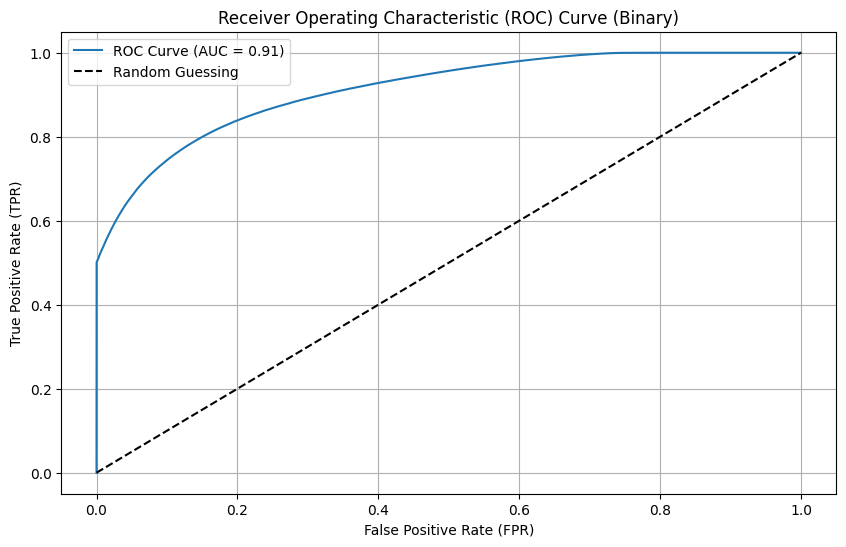

In [8]:
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Binary)')
plt.legend()
plt.grid()
plt.show()

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# Define your desired TPR value
desired_tpr = 0.8

# Find the index of the closest TPR to the desired value
closest_tpr_idx = np.argmin(np.abs(tpr - desired_tpr))



In [22]:

# Get the corresponding threshold
custom_threshold = thresholds[closest_tpr_idx]
print(f"Custom Threshold for TPR={desired_tpr}: {custom_threshold}")



Custom Threshold for TPR=0.8: 0.4810952571535765


In [23]:
# Use the custom threshold to make binary predictions
binary_pred_custom = (binary_probs >= custom_threshold).astype(int)



In [24]:
# Evaluate performance
conf_matrix_custom = confusion_matrix(binary_truth, binary_pred_custom)
accuracy_custom = accuracy_score(binary_truth, binary_pred_custom)

print("Confusion Matrix with Custom Threshold:\n", conf_matrix_custom)


Confusion Matrix with Custom Threshold:
 [[732762 129828]
 [173237 692948]]


In [25]:
print("Accuracy with Custom Threshold:", accuracy_custom)

Accuracy with Custom Threshold: 0.8246937860623852


In [26]:
# Load the saved model
model2_loaded = load_model("model_SimpleRNN_212.h5")

In [28]:
# Generate sequences of the test data of the first chain
X2_test_seq, y2_test_seq = rp.create_sequences(rp.fes.X2_test, rp.fes.y2_test, rp.seq_length)

# Predict the labels for the test set
y_pred2 = model2_loaded.predict(X2_test_seq)

#convert predictions to class labels
y_pred_classes2 = np.argmax(y_pred2, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes2 = np.argmax(y2_test_seq, axis=1)

53464/53464 [==============================] - 228s 4ms/step


In [29]:
# Define the binary mapping
binary_mapping_2 = {
    0: 0,  # Map original class 0 to binary class 0
    3: 0,  # Map original class 3 to binary class 0
    4: 1,  # Map original class 4 to binary class 1
    5: 1,  # Map original class 5 to binary class 1
}


In [30]:
# Use y_pred1 (probabilities) for binary classification
binary_probs_2 = np.zeros(len(y_pred2))
for original_class, binary_class in binary_mapping_2.items():
    binary_probs_2 += y_pred2[:, original_class] * (binary_class == 1)


In [31]:
# Map true labels to binary labels
binary_truth_2 = np.array([binary_mapping_2[x] for x in y_test_classes2])


In [32]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(binary_truth_2, binary_probs_2)
roc_auc = auc(fpr, tpr)

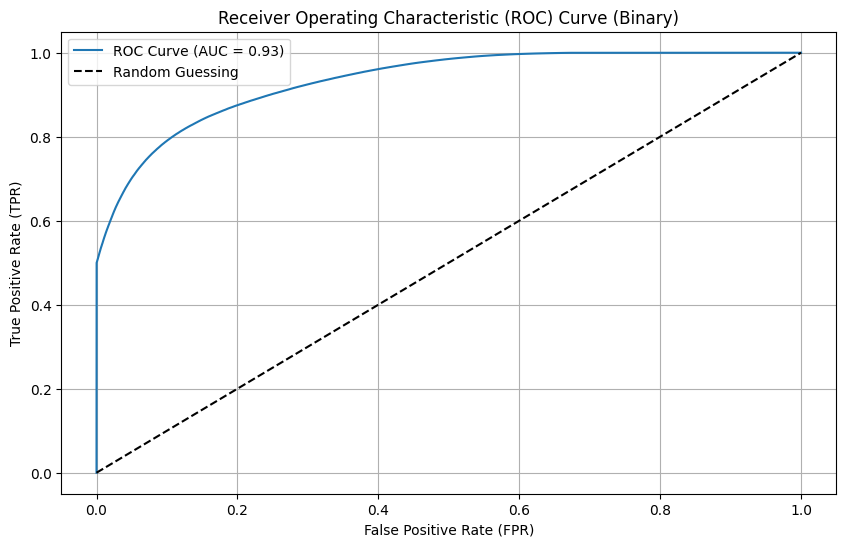

In [33]:
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Binary)')
plt.legend()
plt.grid()
plt.show()

In [49]:
# Define your desired TPR value
desired_tpr = 0.8

# Find the index of the closest TPR to the desired value
closest_tpr_idx = np.argmin(np.abs(tpr - desired_tpr))



In [50]:
# Get the corresponding threshold
custom_threshold = thresholds[closest_tpr_idx]
print(f"Custom Threshold for TPR={desired_tpr}: {custom_threshold}")


Custom Threshold for TPR=0.8: 0.5346531877364333


In [51]:
# Use the custom threshold to make binary predictions
binary_pred_custom = (binary_probs >= custom_threshold).astype(int)

In [52]:
# Evaluate performance
conf_matrix_custom = confusion_matrix(binary_truth, binary_pred_custom)
accuracy_custom = accuracy_score(binary_truth, binary_pred_custom)

print("Confusion Matrix with Custom Threshold:\n", conf_matrix_custom)


Confusion Matrix with Custom Threshold:
 [[757547 105043]
 [198563 667622]]


In [ ]:
print("Accuracy with Custom Threshold:", accuracy_custom)

Accuracy with Custom Threshold: 0.8243808477100837


: 